In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# Load the dataset
df = pd.read_csv("insurance.csv")

In [3]:
# Display first five rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print("Shape of dataset:", df.shape)

Shape of dataset: (1338, 7)


In [5]:
print(df.dtypes)

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
print("Columns:")
print(df.columns)

Columns:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [8]:
# Task 2: Null Value Analysis

In [9]:
# Count missing values in each column
null_count = df.isnull().sum()

print("Missing Values Count:")
print(null_count)

Missing Values Count:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [10]:
# Calculate missing value percentage
null_percentage = (df.isnull().sum() / df.shape[0]) * 100

print("Missing Value Percentage:")
print(null_percentage)

Missing Value Percentage:
age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64


In [11]:
# Create a summary table
null_summary = pd.DataFrame({
    "Missing Count": null_count,
    "Missing Percentage": null_percentage
})

print(null_summary)

          Missing Count  Missing Percentage
age                   0                 0.0
sex                   0                 0.0
bmi                   0                 0.0
children              0                 0.0
smoker                0                 0.0
region                0                 0.0
charges               0                 0.0


In [12]:
# Identify columns with more than 20% missing values
high_null_columns = null_summary[null_summary["Missing Percentage"] > 20]

print("Columns with more than 20% missing values:")
print(high_null_columns)

Columns with more than 20% missing values:
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []


In [13]:
# Fill missing values in numeric columns with median
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

print("Remaining Missing Values:")
print(df.isnull().sum())

Remaining Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [14]:
# Task 3: Duplicate Detection and Removal

In [15]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1


In [16]:
# Shape before removing duplicates
rows_before = df.shape[0]

print("Rows before removing duplicates:", rows_before)

Rows before removing duplicates: 1338


In [17]:
# Remove duplicate rows
df = df.drop_duplicates()

rows_after = df.shape[0]

print("Rows after removing duplicates:", rows_after)

Rows after removing duplicates: 1337


In [18]:
removed_rows = rows_before - rows_after

print("Duplicate rows removed:", removed_rows)

Duplicate rows removed: 1


In [19]:
print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


In [20]:
null_percentage_after = (df.isnull().sum()/df.shape[0])*100

print("Missing Value Percentage After Removing Duplicates")
print(null_percentage_after)

Missing Value Percentage After Removing Duplicates
age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64


In [21]:
comparison = pd.DataFrame({
    "Before (%)": null_percentage,
    "After (%)": null_percentage_after
})

comparison

,Before (%),After (%)
age,0.0,0.0
sex,0.0,0.0
bmi,0.0,0.0
children,0.0,0.0
smoker,0.0,0.0
region,0.0,0.0
charges,0.0,0.0


In [22]:
# Task 4: Data Type Correction

In [23]:
print("Current Data Types:")
print(df.dtypes)

Current Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [24]:
memory_before = df.memory_usage(deep=True).sum()

print("Memory Before Conversion:", memory_before, "bytes")

Memory Before Conversion: 271672 bytes


In [25]:
# Convert repetitive string columns to category
df["sex"] = df["sex"].astype("category")
df["smoker"] = df["smoker"].astype("category")
df["region"] = df["region"].astype("category")

In [26]:
print("Data Types After Conversion:")
print(df.dtypes)

Data Types After Conversion:
age            int64
sex         category
bmi          float64
children       int64
smoker      category
region      category
charges      float64
dtype: object


In [27]:
memory_after = df.memory_usage(deep=True).sum()

print("Memory After Conversion:", memory_after, "bytes")

Memory After Conversion: 58322 bytes


In [28]:
saved = memory_before - memory_after

print("Memory Saved:", saved, "bytes")

print("Percentage Reduction:",
      round((saved / memory_before) * 100, 2), "%")

Memory Saved: 213350 bytes
Percentage Reduction: 78.53 %


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1337 non-null   int64   
 1   sex       1337 non-null   category
 2   bmi       1337 non-null   float64 
 3   children  1337 non-null   int64   
 4   smoker    1337 non-null   category
 5   region    1337 non-null   category
 6   charges   1337 non-null   float64 
dtypes: category(3), float64(2), int64(2)
memory usage: 56.6 KB


In [30]:
# Task 5: Descriptive Statistics and Skewness

In [ ]:
# Display descriptive statistics for numeric columns
print("Descriptive Statistics")
display(df.describe())

In [31]:
numeric_columns = df.select_dtypes(include=['int64','float64']).columns

print(numeric_columns)

Index(['age', 'bmi', 'children', 'charges'], dtype='object')


In [32]:
print("Skewness of Numeric Columns\n")

skew_values = df[numeric_columns].skew()

print(skew_values)

Skewness of Numeric Columns

age         0.054781
bmi         0.283914
children    0.937421
charges     1.515391
dtype: float64


In [33]:
print("Skewness of Numeric Columns\n")

skew_values = df[numeric_columns].skew()

print(skew_values)

Skewness of Numeric Columns

age         0.054781
bmi         0.283914
children    0.937421
charges     1.515391
dtype: float64


In [34]:
skew_table = pd.DataFrame({
    "Column": skew_values.index,
    "Skewness": skew_values.values,
    "Absolute Skewness": skew_values.abs().values
})

display(skew_table)

,Column,Skewness,Absolute Skewness
0,age,0.054781,0.054781
1,bmi,0.283914,0.283914
2,children,0.937421,0.937421
3,charges,1.515391,1.515391


In [35]:
highest_skew_column = skew_values.abs().idxmax()

highest_skew_value = skew_values[highest_skew_column]

print("Column with Highest Absolute Skewness:")
print(highest_skew_column)

print("\nSkewness Value:")
print(highest_skew_value)

Column with Highest Absolute Skewness:
charges

Skewness Value:
1.5153909108403483


In [36]:
if highest_skew_value > 0:
    print(f"{highest_skew_column} is Positively Skewed.")
elif highest_skew_value < 0:
    print(f"{highest_skew_column} is Negatively Skewed.")
else:
    print(f"{highest_skew_column} has a Symmetric Distribution.")

charges is Positively Skewed.


In [37]:
# Task 6: Outlier Detection using IQR

In [38]:
def detect_outliers_iqr(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print("="*50)
    print("Column :", column)
    print("Q1 :", Q1)
    print("Q3 :", Q3)
    print("IQR :", IQR)
    print("Lower Bound :", lower)
    print("Upper Bound :", upper)
    print("Number of Outliers :", len(outliers))

    return outliers

In [39]:
bmi_outliers = detect_outliers_iqr(df, "bmi")

Column : bmi
Q1 : 26.29
Q3 : 34.7
IQR : 8.410000000000004
Lower Bound : 13.674999999999994
Upper Bound : 47.31500000000001
Number of Outliers : 9


In [42]:
charges_outliers = detect_outliers_iqr(df, "charges")

Column : charges
Q1 : 4746.344
Q3 : 16657.71745
IQR : 11911.37345
Lower Bound : -13120.716174999998
Upper Bound : 34524.777625
Number of Outliers : 139


In [43]:
print("BMI Outliers")
display(bmi_outliers.head())

print("\nCharges Outliers")
display(charges_outliers.head())

BMI Outliers


,age,sex,bmi,children,smoker,region,charges
116,58,male,49.06,0,no,southeast,11381.32540
286,46,female,48.07,2,no,northeast,9432.92530
401,47,male,47.52,1,no,southeast,8083.91980
543,54,female,47.41,0,yes,southeast,63770.42801
847,23,male,50.38,1,no,southeast,2438.05520



Charges Outliers


,age,sex,bmi,children,smoker,region,charges
14,27,male,42.13,0,yes,southeast,39611.7577
19,30,male,35.30,0,yes,southwest,36837.4670
23,34,female,31.92,1,yes,northeast,37701.8768
29,31,male,36.30,2,yes,southwest,38711.0000
30,22,male,35.60,0,yes,southwest,35585.5760


In [44]:
outlier_summary = pd.DataFrame({

    "Column":["bmi","charges"],

    "Outlier Count":[
        len(bmi_outliers),
        len(charges_outliers)
    ]

})

display(outlier_summary)

,Column,Outlier Count
0,bmi,9
1,charges,139


In [45]:
# Visualization 1: Line Plot

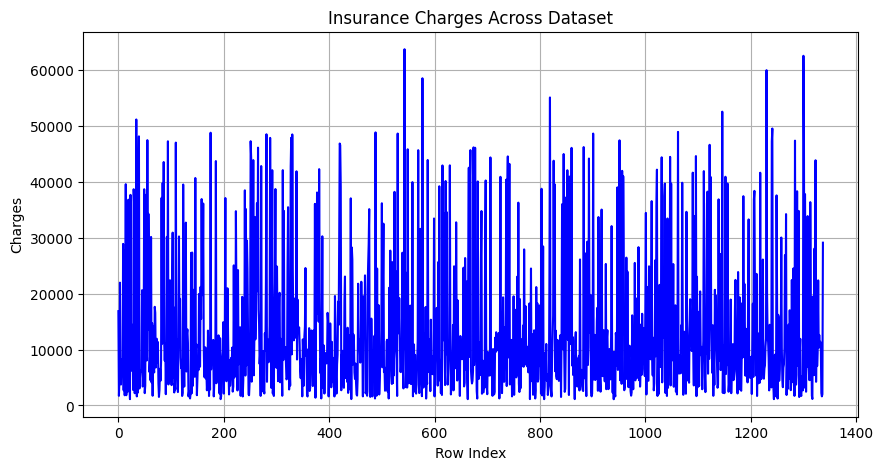

In [46]:
plt.figure(figsize=(10,5))

plt.plot(df.index, df["charges"], color="blue", linewidth=1.5)

plt.title("Insurance Charges Across Dataset")

plt.xlabel("Row Index")

plt.ylabel("Charges")

plt.grid(True)

plt.show()

In [47]:
# Visualization 2: Bar Chart

/tmp/ipykernel_930/2059021281.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_charge = df.groupby("region")["charges"].mean()


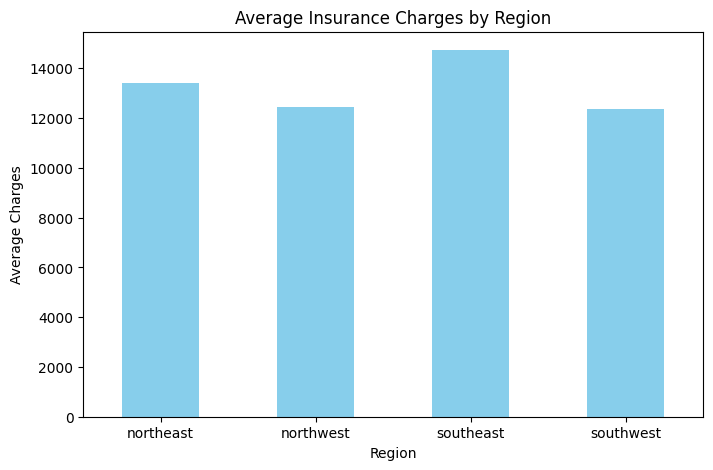

In [48]:
average_charge = df.groupby("region")["charges"].mean()

plt.figure(figsize=(8,5))

average_charge.plot(kind="bar", color="skyblue")

plt.title("Average Insurance Charges by Region")

plt.xlabel("Region")

plt.ylabel("Average Charges")

plt.xticks(rotation=0)

plt.show()

In [49]:
# Visualization 3: Histogram of Charges

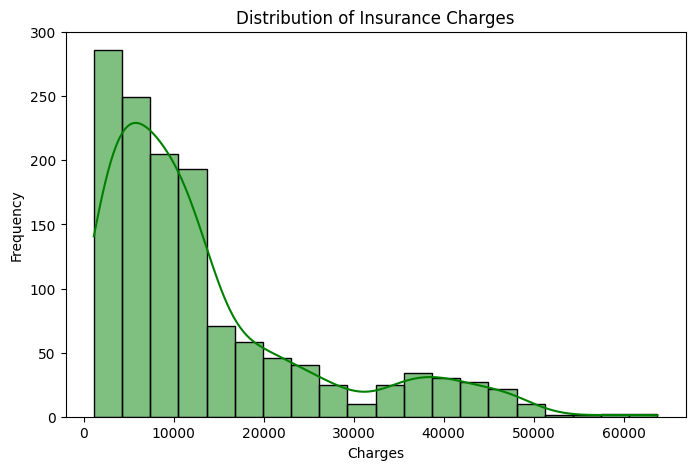

In [50]:
plt.figure(figsize=(8,5))

sns.histplot(df["charges"], bins=20, kde=True, color="green")

plt.title("Distribution of Insurance Charges")

plt.xlabel("Charges")

plt.ylabel("Frequency")

plt.show()

In [51]:
# Visualization 4: Scatter Plot

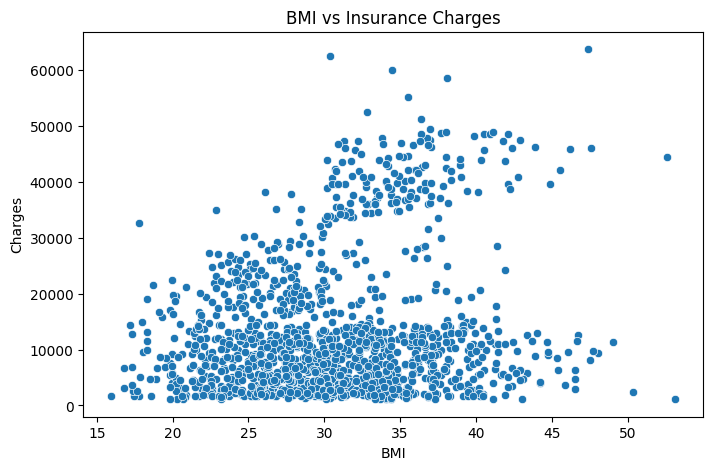

In [52]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="bmi", y="charges", data=df)

plt.title("BMI vs Insurance Charges")

plt.xlabel("BMI")

plt.ylabel("Charges")

plt.show()

In [53]:
# Visualization 5: Box Plot

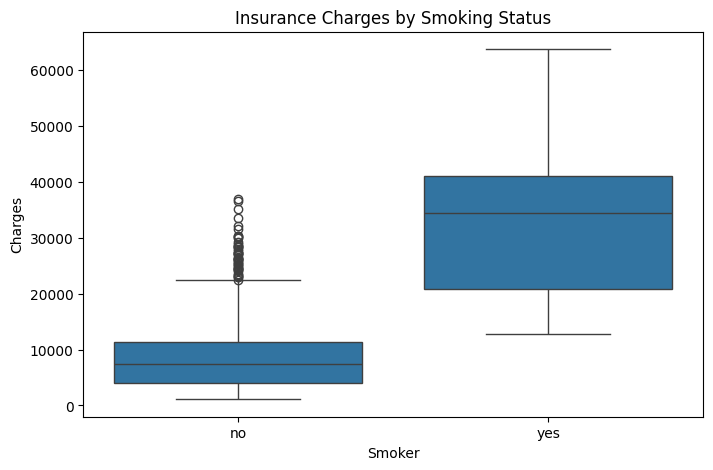

In [54]:
plt.figure(figsize=(8,5))

sns.boxplot(x="smoker", y="charges", data=df)

plt.title("Insurance Charges by Smoking Status")

plt.xlabel("Smoker")

plt.ylabel("Charges")

plt.show()

In [ ]:
# Visualization 6: Correlation Heatmap

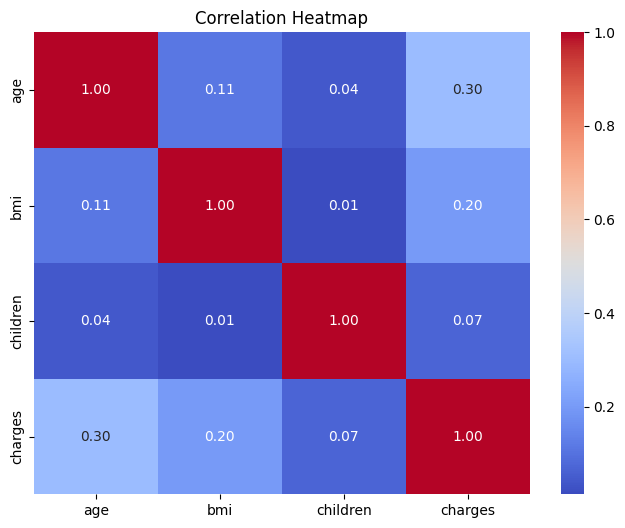

In [55]:
# Correlation matrix for numeric columns
correlation_matrix = df.select_dtypes(include=["int64", "float64"]).corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [56]:
corr = correlation_matrix.abs()

# Remove self-correlation
np.fill_diagonal(corr.values, 0)

highest_pair = corr.unstack().idxmax()
highest_value = corr.unstack().max()

print("Highest Correlated Pair:", highest_pair)
print("Correlation Value:", highest_value)

Highest Correlated Pair: ('age', 'charges')
Correlation Value: 0.2983082125097863


In [ ]:
# Task 9: Mean vs Median Comparison

In [57]:
# Compute skewness again
skewness = df.select_dtypes(include=['int64', 'float64']).skew()

# Select two columns with highest absolute skewness
top2_skewed = skewness.abs().sort_values(ascending=False).head(2)

print("Top Two Skewed Columns")
print(top2_skewed)

Top Two Skewed Columns
charges     1.515391
children    0.937421
dtype: float64


In [58]:
comparison = []

for col in top2_skewed.index:

    comparison.append({
        "Column": col,
        "Mean": df[col].mean(),
        "Median": df[col].median(),
        "Skewness": df[col].skew()
    })

comparison_df = pd.DataFrame(comparison)

display(comparison_df)

,Column,Mean,Median,Skewness
0,charges,13279.121487,9386.1613,1.515391
1,children,1.095737,1.0000,0.937421


In [59]:
for col in top2_skewed.index:

    df[col] = df[col].fillna(df[col].median())

print(df[top2_skewed.index].isnull().sum())

charges     0
children    0
dtype: int64


In [60]:
# Task 10: Spearman Rank Correlation Analysis

In [61]:
# Pearson Correlation Matrix
pearson_corr = df.select_dtypes(include=['int64', 'float64']).corr(method='pearson')

print("Pearson Correlation Matrix")
display(pearson_corr)

Pearson Correlation Matrix


,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


In [62]:
# Spearman Correlation Matrix
spearman_corr = df.select_dtypes(include=['int64', 'float64']).corr(method='spearman')

print("Spearman Correlation Matrix")
display(spearman_corr)

Spearman Correlation Matrix


,age,bmi,children,charges
age,1.000000,0.107897,0.055813,0.533523
bmi,0.107897,1.000000,0.015643,0.119585
children,0.055813,0.015643,1.000000,0.132200
charges,0.533523,0.119585,0.132200,1.000000


In [63]:
# Difference between Spearman and Pearson
difference = (spearman_corr - pearson_corr).abs()

print("Absolute Difference Matrix")
display(difference)

Absolute Difference Matrix


,age,bmi,children,charges
age,0.000000,0.001447,0.014277,0.235215
bmi,0.001447,0.000000,0.002889,0.078816
children,0.014277,0.002889,0.000000,0.064811
charges,0.235215,0.078816,0.064811,0.000000


In [64]:
# Convert matrix into pairs
diff_pairs = difference.unstack().reset_index()
diff_pairs.columns = ["Feature 1", "Feature 2", "Difference"]

# Remove duplicate pairs and self-correlations
diff_pairs = diff_pairs[diff_pairs["Feature 1"] < diff_pairs["Feature 2"]]

# Top 3 differences
top3 = diff_pairs.sort_values(by="Difference", ascending=False).head(3)

print("Top 3 Column Pairs with Largest Difference")
display(top3)

Top 3 Column Pairs with Largest Difference


,Feature 1,Feature 2,Difference
3,age,charges,0.235215
7,bmi,charges,0.078816
14,charges,children,0.064811


In [ ]:
# Task 11: Grouped Aggregation

In [65]:
grouped = df.groupby("smoker")["charges"].agg(["mean", "std", "count"])

print("Grouped Aggregation")
display(grouped)

Grouped Aggregation


/tmp/ipykernel_930/1996308085.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("smoker")["charges"].agg(["mean", "std", "count"])


,mean,std,count
smoker,,,
no,8440.660307,5992.973800,1063
yes,32050.231832,11541.547176,274


In [66]:
highest_mean_group = grouped["mean"].idxmax()
highest_mean_value = grouped["mean"].max()

print("Highest Mean Group:", highest_mean_group)
print("Mean Value:", highest_mean_value)

Highest Mean Group: yes
Mean Value: 32050.23183153285


In [67]:
highest_std_group = grouped["std"].idxmax()
highest_std_value = grouped["std"].max()

print("Highest Standard Deviation Group:", highest_std_group)
print("Standard Deviation:", highest_std_value)

Highest Standard Deviation Group: yes
Standard Deviation: 11541.547175589123


In [68]:
highest_mean = grouped["mean"].max()
lowest_mean = grouped["mean"].min()

ratio = highest_mean / lowest_mean

print("Highest Mean / Lowest Mean Ratio =", round(ratio, 2))

Highest Mean / Lowest Mean Ratio = 3.8


In [69]:
print("Interpretation")
print("- High within-group standard deviation means the feature alone cannot perfectly predict charges.")
print("- A large mean ratio suggests that smoking status carries strong predictive information.")

Interpretation
- High within-group standard deviation means the feature alone cannot perfectly predict charges.
- A large mean ratio suggests that smoking status carries strong predictive information.


In [70]:
# Task 12: Save Cleaned Dataset

In [71]:
df.to_csv("cleaned_data.csv", index=False)

print("cleaned_data.csv has been saved successfully!")

cleaned_data.csv has been saved successfully!


In [72]:
import os

print(os.listdir())

['.config', 'insurance.csv', 'cleaned_data.csv', 'sample_data']


In [73]:
import os

os.makedirs("figures", exist_ok=True)

print("Figures folder created successfully!")

Figures folder created successfully!


In [74]:
plt.show()

In [75]:
plt.tight_layout()
plt.savefig("figures/line_plot.png", dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>

In [77]:
plt.tight_layout()
plt.savefig("figures/bar_chart.png", dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>

In [78]:
plt.tight_layout()
plt.savefig("figures/histogram.png", dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>

In [79]:
plt.tight_layout()
plt.savefig("figures/scatter_plot.png", dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>

In [80]:
plt.tight_layout()
plt.savefig("figures/box_plot.png", dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>

In [81]:
plt.tight_layout()
plt.savefig("figures/heatmap.png", dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>

In [82]:
import os

os.listdir("figures")

['histogram.png',
 'heatmap.png',
 'scatter_plot.png',
 'line_plot.png',
 'bar_chart.png',
 'box_plot.png']